## packages

In [1]:
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
import warnings
from dateutil.relativedelta import relativedelta
from dateutil import parser
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

## data prep

In [3]:
# Function call to process the tradewed data file
def data_preprocess(filepath):
    rawdata = pd.read_csv(filepath)
    rawdata = rawdata.loc[rawdata['ACCEPTEDVOL'] != 0] # Ignore trade stamps with zero volume
    # Remove BILLs , STRIPs and TRSY FRN data to skip the computation from yield to price for Bills and negative spreads for Strips + Treasury FRN
    substring = 'Bill'
    substring2 = 'Strip'
    substring3 = 'TRSY FRN'
    filter = rawdata['MATURITY_RANGE'].str.contains(substring)
    rawdata = rawdata[~filter]
    filter2 = rawdata['MATURITY_RANGE'].str.contains(substring2)
    rawdata = rawdata[~filter2]
    filter3 = rawdata['MATURITY_RANGE'].str.contains(substring3)
    rawdata = rawdata[~filter3]
    rawdata = rawdata.loc[rawdata['TRADETYPE'] == 'OUTRIGHT'] # Only consider outright trades
    rawdata.reset_index(inplace=True)
    # Convert TRADETIME , MATURITY DATE and TRADE DATE to datetime and assign new index
    tradetime = []
    tradedate = []
    maturitydate = []
    for i in range(rawdata.shape[0]):
        tradetime.append(datetime.datetime.strptime(rawdata['TRADETIME'].iloc[i].rstrip(' Z'), "%Y-%m-%d %H:%M:%S.%f"))
        tradedate.append(datetime.datetime.strptime(rawdata['TRADEDATE'].iloc[i], '%m/%d/%y'))
        maturitydate.append(datetime.datetime.strptime(rawdata['MATURITY_DATE'].iloc[i], '%m/%d/%y'))
    rawdata['TIMESTAMP'] = tradetime
    rawdata['TRADEDATE'] = tradedate
    rawdata['MATURITY_DATE'] = maturitydate
    rawdata.set_index('TIMESTAMP', inplace= True)
    rawdata.sort_index(inplace=True)
    return rawdata

In [5]:
tw1 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 1.csv')
tw2 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 2.csv')
tw3 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 3.csv')
tw4 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 4.csv')
rawdata = pd.concat([tw1, tw2, tw3, tw4], axis =0)

In [6]:
rawdata.columns

Index(['index', 'TRADEDATE', 'DEALER', 'DEALERCOUNT', 'ACCEPTED',
       'SEEN_INQUIRY', 'ACCEPTEDVOL', 'SEENVOLUME', 'PRICE', 'TRADETIME',
       'INSTRUMENT', 'INSTRUMENT_DESC', 'MATURITY_DATE', 'MATURITY_RANGE',
       'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'PROTOCOL', 'TRADETYPE',
       'SOURCE'],
      dtype='object')

In [7]:
rawdata.head(5)

,index,TRADEDATE,DEALER,DEALERCOUNT,ACCEPTED,SEEN_INQUIRY,ACCEPTEDVOL,SEENVOLUME,PRICE,TRADETIME,...,INSTRUMENT_DESC,MATURITY_DATE,MATURITY_RANGE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,PROTOCOL,TRADETYPE,SOURCE
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,47059,2023-10-02,D69,5,1,1,1100.90,1100.90,99.761887,2023-10-02 06:47:43.000 Z,...,"T 4 5/8 <MD2Y,2462045> 5yr",2028-09-30,Note 3.5 - 5.5 Year,4.625,BUY,99.769531,99.753906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,19829,2023-10-02,D38,5,1,1,3939.00,3939.00,99.691574,2023-10-02 06:47:43.000 Z,...,"T 5 <MD2Y,2460919>",2025-08-31,Note 1.5 - 3.5 Year,5.000,BUY,99.703125,99.691406,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,50786,2023-10-02,D28,5,1,1,297.95,297.95,89.461106,2023-10-02 06:47:43.000 Z,...,"T 1 1/8 <MD2Y,2461345>",2026-10-31,Note 1.5 - 3.5 Year,1.125,BUY,89.488281,89.433594,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,24582,2023-10-02,D38,5,1,1,676.70,676.70,90.133013,2023-10-02 06:47:43.000 Z,...,"T 4 1/8 <MD2Y,2471130> 30yr",2053-08-15,Note >10 Year,4.125,BUY,90.160156,90.128906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,57986,2023-10-02,D11,5,1,1,176.75,176.75,60.906450,2023-10-02 06:47:43.000 Z,...,"T 2 1/4 <MD2Y,2470583>",2052-02-15,Note >10 Year,2.250,BUY,60.960938,60.882812,REG List,OUTRIGHT,TW


In [11]:
filtered_rawdata = rawdata[['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE','MATURITY_DATE', 'TRADEDATE',"COUPON_RATE",'SIDE','COMP_ASK','COMP_BID']].copy()
filtered_rawdata.head()

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID
TIMESTAMP,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812


In [13]:
filtered_rawdata.shape

(50741, 11)

In [15]:
filtered_rawdata['SIGN'] = filtered_rawdata['SIDE'].apply(lambda x: 1 if x == 'BUY' else -1)
filtered_rawdata['SIGNED_VOLUME'] = filtered_rawdata['ACCEPTEDVOL'] * filtered_rawdata['SIGN'] * 10

filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME
TIMESTAMP,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,20200.00,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0
2023-12-29 13:51:46,D50,12120.00,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0
2023-12-29 13:51:46,D28,25250.00,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0


In [17]:
# Calculate years to maturity
ytm = []
for i in range(0,rawdata.shape[0]):
    ytm.append(relativedelta(filtered_rawdata['MATURITY_DATE'].iloc[i],filtered_rawdata['TRADEDATE'].iloc[i]).years)
filtered_rawdata['Years to Maturity'] = ytm
# calculate spreads
filtered_rawdata['Spread'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID'])/2

In [18]:
filtered_rawdata['MATURITY_RANGE'].unique()

array(['Note 3.5 - 5.5 Year', 'Note 1.5 - 3.5 Year', 'Note >10 Year',
       'Note 5.5 - 10 Year', 'Note 0 - 1.5 Year', 'TIPS 0 - 5 year',
       'TIPS 5 - 10 year', 'TIPS > 10 year'], dtype=object)

In [12]:
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,20200.00,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344
2023-12-29 13:51:46,D50,12120.00,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875
2023-12-29 13:51:46,D28,25250.00,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250


## Non-linear cost Function

In [23]:
def nonlinear_cost(delta_q, lambda_p, p):
    return lambda_p * np.abs(delta_q) ** p


In [25]:
def feedback_policy(signal_ft, holdings_qt_minus_1, lambda_p, gamma, sigma, alpha, rho, p):
    """
    Calculate optimal trade size incorporating nonlinear price impact.
    
    Parameters:
        signal_ft (float): Current signal (predictor) value.
        holdings_qt_minus_1 (float): Holdings at previous time step.
        lambda_p (float): Effective quadratic cost parameter.
        gamma (float): Risk aversion parameter.
        sigma (float): Volatility of returns.
        alpha (float): Scaling for return predictability.
        rho (float): Persistence of the signal.
        p (float): Exponent for power-law transaction costs.
        
    Returns:
        float: Optimal trade size.
    """
    # Effective cost parameters adjusted for nonlinear impact
    c_eff = gamma * sigma**2 / (4 * lambda_p * (1 + np.sqrt(1 + 8 * lambda_p / (gamma * sigma**2))))
    k_f = alpha * rho / (1 - rho + c_eff)
    k_q = 1 / (1 + c_eff)
    
    delta_q = k_f * signal_ft + (k_q - 1) * holdings_qt_minus_1
    return delta_q


In [31]:
import numpy as np
import pandas as pd

def calculate_impact_and_liquidity(data, beta=0.142, delta_t=1/252, lambda_value=1.35e-7, p=1.6):
    """
    Calculate market impact and liquidity with power-law price impact.
    
    Parameters:
        data (pd.DataFrame): Trading data with required columns
        beta (float): Decay rate of market impact (0.142 from paper)
        delta_t (float): Time step in years (default 1 trading day)
        lambda_value (float): Impact coefficient (1.35e-7 from paper)
        p (float): Power law exponent (1.6 from paper)
    
    Returns:
        pd.DataFrame: Data with added impact and liquidity measures
    """
    data = data.copy()
    
    # Calculate absolute volume and return
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()
    data['RETURN'] = data['PRICE'].pct_change()
    data['F_t_diff'] = data['SIGNED_VOLUME'].diff()
    data.dropna(inplace=True)
    
    # Initialize arrays
    I_values = np.zeros(len(data))  
    I_temp = np.zeros(len(data))    
    v_values = np.zeros(len(data))  
    
    # Initial values
    v_values[0] = data['ABS_VOLUME'].iloc[0]
    
    # Calculate initial impact using power law
    if data['ADV'].iloc[0] != 0:
        normalized_vol = data['SIGNED_VOLUME'].iloc[0] / data['ADV'].iloc[0]
        I_values[0] = (lambda_value * data['Daily_Volatility'].iloc[0] * 
                      np.sign(normalized_vol) * np.abs(normalized_vol)**(p-1))
        I_temp[0] = I_values[0]
    
    # Iterate over time steps
    for i in range(1, len(data)):
        sigma_value = data['Daily_Volatility'].iloc[i]
        qt = data['qt'].iloc[i]
        adv_value = data['ADV'].iloc[i]
        
        # Calculate v_t+delta_t (liquidity)
        v_values[i] = v_values[i-1] * np.exp(-beta * delta_t) + abs(qt)
        
        # Calculate power-law impact
        if adv_value != 0:
            # Decay previous impact
            I_temp[i] = I_temp[i-1] * np.exp(-beta * delta_t)
            
            # Add new impact using power law
            normalized_vol = qt / adv_value
            new_impact = (lambda_value * sigma_value * 
                        np.sign(normalized_vol) * np.abs(normalized_vol)**(p-1))
            
            # Total impact combines decayed previous impact and new impact
            I_values[i] = I_temp[i] + new_impact
            I_temp[i] += new_impact
            
    # Add calculated values to DataFrame
    data['I_t'] = I_values        # Total impact
    data['I_temp'] = I_temp       # Temporary impact component
    data['v_t'] = v_values        # Liquidity measure
    
    # Calculate expected price change
    data['Expected_Price_Change'] = data['I_t'] * data['Daily_Volatility']
    
    # Calculate realized impact
    data['Realized_Impact'] = data['RETURN'] - data['Expected_Price_Change']
    
    return data

def analyze_impact_decay(data, trade_size_threshold=None):
    """
    Analyze how impact decays after large trades.
    
    Parameters:
        data (pd.DataFrame): Output from calculate_impact_and_liquidity
        trade_size_threshold (float): Minimum absolute trade size to consider
        
    Returns:
        dict: Impact decay statistics
    """
    if trade_size_threshold is None:
        # Default to 2 standard deviations above mean trade size
        trade_size_threshold = data['ABS_VOLUME'].mean() + 2 * data['ABS_VOLUME'].std()
    
    # Identify large trades
    large_trades = data[data['ABS_VOLUME'] > trade_size_threshold]
    
    if len(large_trades) == 0:
        return {"message": "No trades above threshold found"}
    
    decay_stats = {
        'avg_initial_impact': large_trades['I_t'].mean(),
        'median_initial_impact': large_trades['I_t'].median(),
        'avg_decay_rate': -np.log(large_trades['I_temp'] / large_trades['I_t']).mean(),
        'avg_half_life': np.log(2) / (-np.log(large_trades['I_temp'] / large_trades['I_t']).mean())
    }
    
    return decay_stats

## daily_vol, adv, beta

In [14]:
filtered_rawdata.MATURITY_RANGE.value_counts()

MATURITY_RANGE
Note 1.5 - 3.5 Year    12244
Note 0 - 1.5 Year       9955
Note >10 Year           8946
Note 5.5 - 10 Year      8760
Note 3.5 - 5.5 Year     7661
TIPS 0 - 5 year         1620
TIPS > 10 year           782
TIPS 5 - 10 year         773
Name: count, dtype: int64

In [15]:
group1 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == 'Note 0 - 1.5 Year']
group1

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:50:42,D50,3009.800,94.960769,91282CDH1,Note 0 - 1.5 Year,2024-11-15,2023-10-02,0.750,SELL,94.984375,94.937500,-1,-30098.00,1,0.023438
2023-10-02 07:23:23,D28,102.313,99.757644,912828T91,Note 0 - 1.5 Year,2023-10-31,2023-10-02,1.625,SELL,99.781250,99.726562,-1,-1023.13,0,0.027344
2023-10-02 08:22:38,D28,5050.000,98.827957,91282CFN6,Note 0 - 1.5 Year,2024-09-30,2023-10-02,4.250,SELL,98.847656,98.808594,-1,-50500.00,0,0.019531
2023-10-02 08:33:25,D71,3838.000,99.409988,91282CAW1,Note 0 - 1.5 Year,2023-11-15,2023-10-02,0.250,SELL,99.441406,99.386719,-1,-38380.00,0,0.027344
2023-10-02 09:00:46,D38,7575.000,96.804519,9128282U3,Note 0 - 1.5 Year,2024-08-31,2023-10-02,1.875,SELL,96.824219,96.789062,-1,-75750.00,0,0.017578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:07,D50,13130.000,96.874832,91282CCX7,Note 0 - 1.5 Year,2024-09-15,2023-12-29,0.375,SELL,96.917969,96.843750,-1,-131300.00,0,0.037109
2023-12-29 13:51:46,D50,20200.000,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.00,0,0.027344
2023-12-29 13:51:46,D28,25250.000,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.00,1,0.031250


In [16]:
group1['TRADEDATE'] = pd.to_datetime(group1['TRADEDATE'])

# Group by 'TRADEDATE' and calculate the daily volatility as the standard deviation of 'PRICE'
daily_volatility = group1.groupby('TRADEDATE')['PRICE'].std()

# Map the daily volatility back to the original DataFrame
group1['Daily_Volatility'] = group1['TRADEDATE'].map(daily_volatility)

In [17]:
group1.Daily_Volatility

TIMESTAMP
2023-10-02 06:50:42    1.637854
2023-10-02 07:23:23    1.637854
2023-10-02 08:22:38    1.637854
2023-10-02 08:33:25    1.637854
2023-10-02 09:00:46    1.637854
                         ...   
2023-12-29 13:51:07    1.275545
2023-12-29 13:51:46    1.275545
2023-12-29 13:51:46    1.275545
2023-12-29 13:51:46    1.275545
2023-12-29 13:51:46    1.275545
Name: Daily_Volatility, Length: 9955, dtype: float64

In [18]:
def calculate_monthly_adv_separately(data):
    # resample volume to daily
    daily_vol = data['ACCEPTEDVOL'].resample('D').sum() * 10
    print("Daily Total Volume:\n", daily_vol.head(10))

    october_total_vol = daily_vol[0]  # total volume for October
    december_total_vol = daily_vol[2]  # total volume for December
    # Calculate the number of trading days for October and December
    october_trading_days = data['ACCEPTEDVOL']['2023-10'].count()
    december_trading_days = data['ACCEPTEDVOL']['2023-12'].count()

    # Calculate ADV
    october_adv = october_total_vol / october_trading_days
    december_adv = december_total_vol / december_trading_days

    # Assign the ADV value
    data.loc['2023-10', 'ADV'] = october_adv
    data.loc['2023-12', 'ADV'] = december_adv

    # Forward fill for consistency
    data['ADV'].fillna(method='ffill', inplace=True)
    data['ADV'].fillna(method='bfill', inplace=True)

    return data[['ADV']], october_total_vol, december_total_vol

In [19]:
group1[['ADV']], october_total_vol, december_total_vol = calculate_monthly_adv_separately(group1)

Daily Total Volume:
 TIMESTAMP
2023-10-02    3395752.31
2023-10-03    1409081.30
2023-10-04     610457.13
2023-10-05    2000840.30
2023-10-06     801069.38
2023-10-07          0.00
2023-10-08          0.00
2023-10-09          0.00
2023-10-10    1398221.78
2023-10-11    1051314.05
Freq: D, Name: ACCEPTEDVOL, dtype: float64


In [20]:
group1.ADV

TIMESTAMP
2023-10-02 06:50:42    682.975123
2023-10-02 07:23:23    682.975123
2023-10-02 08:22:38    682.975123
2023-10-02 08:33:25    682.975123
2023-10-02 09:00:46    682.975123
                          ...    
2023-12-29 13:51:07    122.507953
2023-12-29 13:51:46    122.507953
2023-12-29 13:51:46    122.507953
2023-12-29 13:51:46    122.507953
2023-12-29 13:51:46    122.507953
Name: ADV, Length: 9955, dtype: float64

In [21]:
print('OCT',october_total_vol)
print('DEC',december_total_vol)

OCT 3395752.3100000005
DEC 610457.13


In [22]:
import math
beta = math.log(2)/1 # half-life is 30min, bin is 60 min
print('beta:',beta)

beta: 0.6931471805599453


## qt

In [23]:
def add_resampled_volume(df):
    result_df = df.copy()
    bin = result_df.index.floor('60T')
    # Calculate qt for each 30-minute window
    qt = (result_df.groupby(bin)['SIGNED_VOLUME']
                .transform('sum'))
    result_df['qt'] = qt

    return result_df

In [24]:
group1['SIGN'].unique()

array([-1,  1])

In [25]:
group1 = add_resampled_volume(group1)
qt = group1['SIGNED_VOLUME'].resample('60T').sum()

# Compare results
print(group1[['SIGNED_VOLUME', 'qt']])
print(qt)

                     SIGNED_VOLUME           qt
TIMESTAMP                                      
2023-10-02 06:50:42      -30098.00    -30098.00
2023-10-02 07:23:23       -1023.13     -1023.13
2023-10-02 08:22:38      -50500.00    -88880.00
2023-10-02 08:33:25      -38380.00    -88880.00
2023-10-02 09:00:46      -75750.00    -71871.60
...                            ...          ...
2023-12-29 13:51:07     -131300.00 -12203875.45
2023-12-29 13:51:46     -202000.00 -12203875.45
2023-12-29 13:51:46     -252500.00 -12203875.45
2023-12-29 13:51:46     -202000.00 -12203875.45
2023-12-29 13:51:46       -2020.00 -12203875.45

[9955 rows x 2 columns]
TIMESTAMP
2023-10-02 06:00:00      -30098.00
2023-10-02 07:00:00       -1023.13
2023-10-02 08:00:00      -88880.00
2023-10-02 09:00:00      -71871.60
2023-10-02 10:00:00     -382616.28
                          ...     
2023-12-29 09:00:00       -6373.10
2023-12-29 10:00:00      408322.80
2023-12-29 11:00:00   -17128833.41
2023-12-29 12:00:00    -52

In [26]:
(group1.qt == 0).value_counts()

qt
False    9955
Name: count, dtype: int64

In [27]:
# Function to calculate I_t and v_t using the given equations from book
def calculate_impact_and_liquidity(data, beta, delta_t, lambda_value):
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()
    data['RETURN'] = data['PRICE'].pct_change()
    data['F_t_diff'] = data['SIGNED_VOLUME'].diff()
    data.dropna(inplace=True)

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma_value = data['Daily_Volatility'].iloc[i]
        qt = data['qt'].iloc[i]
        adv_value = data['ADV'].iloc[i]
        # Calculate v_t+delta_t using the exponential moving sum of volume
        v_values[i] = v_values[i-1] + (-beta * v_values[i-1] * delta_t + abs(qt))

        # Calculate I_t+delta_t using the impact equation
        if adv_value != 0:
            I_values[i] = I_values[i-1] + (-beta * I_values[i-1] * delta_t +
                                           lambda_value * sigma_value * (qt / np.sqrt(adv_value*v_values[i])))

    # Append the calculated values to the DataFrame for further analysis
    data['I_t'] = I_values
    data['v_t'] = v_values

    # Include PRICE in the returned DataFrame to calculate Delta_P in the next function
    return data

### func to find lambda

In [28]:
import numpy as np
import math
from sklearn.linear_model import LinearRegression

def calculate_impact_and_liquidity(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()
    
    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60
    
    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours
    
    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))
    
    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]
    
    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay
    
    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]
        
        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)
        
        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]
    
    data['I_t'] = I_values
    data['v_t'] = v_values
    return data, beta

def estimate_lambda(data, initial_lambda, h_minutes, delta_t=1/24):
    """
    Estimate optimal lambda for a given time interval h_minutes
    h_minutes: horizon for returns (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    # Calculate impact states
    impact_data, beta = calculate_impact_and_liquidity(data, h_minutes, delta_t)
    
    # Calculate returns using h periods
    h_periods = int(len(impact_data) * (h_minutes/(24*60)))  # Convert minutes to fraction of day
    h_periods = max(1, h_periods)  # Ensure at least 1 period
    
    # Calculate Δ^h P = (P_{t+h} - P_t)/P_t using h as the horizon
    impact_data['Delta_h_P'] = (impact_data['PRICE'].shift(-h_periods) - impact_data['PRICE']) / impact_data['PRICE']
    
    # Calculate Δ^h I = I_{t+h} - I_t using h as the horizon
    impact_data['Delta_h_I'] = impact_data['I_t'].shift(-h_periods) - impact_data['I_t']
    
    # Remove NaN values
    impact_data.dropna(inplace=True)
    
    # Run regression: Δ^h P = Δ^h I(λ) + ϵ
    X = impact_data[['Delta_h_I']]
    y = impact_data['Delta_h_P']
    
    model = LinearRegression()
    model.fit(X, y)
    
    optimal_lambda = model.coef_[0]
    r_squared = model.score(X, y)
    
    return optimal_lambda, r_squared, beta, impact_data

def grid_search_lambda(data, h_values_minutes, delta_t=1/24):
    """
    Test different time intervals to find optimal lambda
    """
    results = []
    for h_minutes in h_values_minutes:
        optimal_lambda, r_squared, beta, _ = estimate_lambda(data, 1.0, h_minutes, delta_t)
        results.append({
            'h_minutes': h_minutes,
            'h_hours': h_minutes/60,
            'h_periods': max(1, int(len(data) * (h_minutes/(24*60)))),
            'beta': beta,
            'lambda': optimal_lambda,
            'r_squared': r_squared
        })
    return results

In [29]:
h_values_minutes = [6, 12, 18, 24, 30, 48, 60, 90, 120]  # horizons in minutes
delta_t = 1/24  # 1 hour for impact decay
results = grid_search_lambda(group1, h_values_minutes, delta_t)

def print_results(results):
    print("\nSummary of Results:")
    print("-" * 80)
    print(f"{'h (min)':>10} {'beta':>12} {'lambda':>12} {'R²':>12}")
    print("-" * 80)
    
    for result in results:
        h_min = result['h_minutes']
        beta = result['beta']
        lambda_val = result['lambda']
        r2 = result['r_squared']
        
        print(f"{h_min:10.1f} {beta:12.6f} {lambda_val:12.6f} {r2:12.6f}")
    print("-" * 80)

# After running grid_search_lambda, use:
results = grid_search_lambda(group1, h_values_minutes, delta_t)
print_results(results)


Summary of Results:
--------------------------------------------------------------------------------
   h (min)         beta       lambda           R²
--------------------------------------------------------------------------------
       6.0     6.931472    -0.000001     0.000009
      12.0     3.465736    -0.000001     0.000037
      18.0     2.310491     0.000001     0.000088
      24.0     1.732868     0.000003     0.000446
      30.0     1.386294     0.000003     0.001132
      48.0     0.866434     0.000001     0.000435
      60.0     0.693147     0.000002     0.001280
      90.0     0.462098     0.000002     0.002015
     120.0     0.346574     0.000001     0.000410
--------------------------------------------------------------------------------


set $\lambda = 0.000002$

In [37]:
def ow(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()
    
    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60
    
    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours
    
    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))
    
    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]
    
    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay
    
    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]
        
        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)
        
        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]
    
    data['I_t'] = I_values
    data['v_t'] = v_values
    return data


In [38]:
df_it = ow(group1, h_minutes=120, delta_t=1/24)

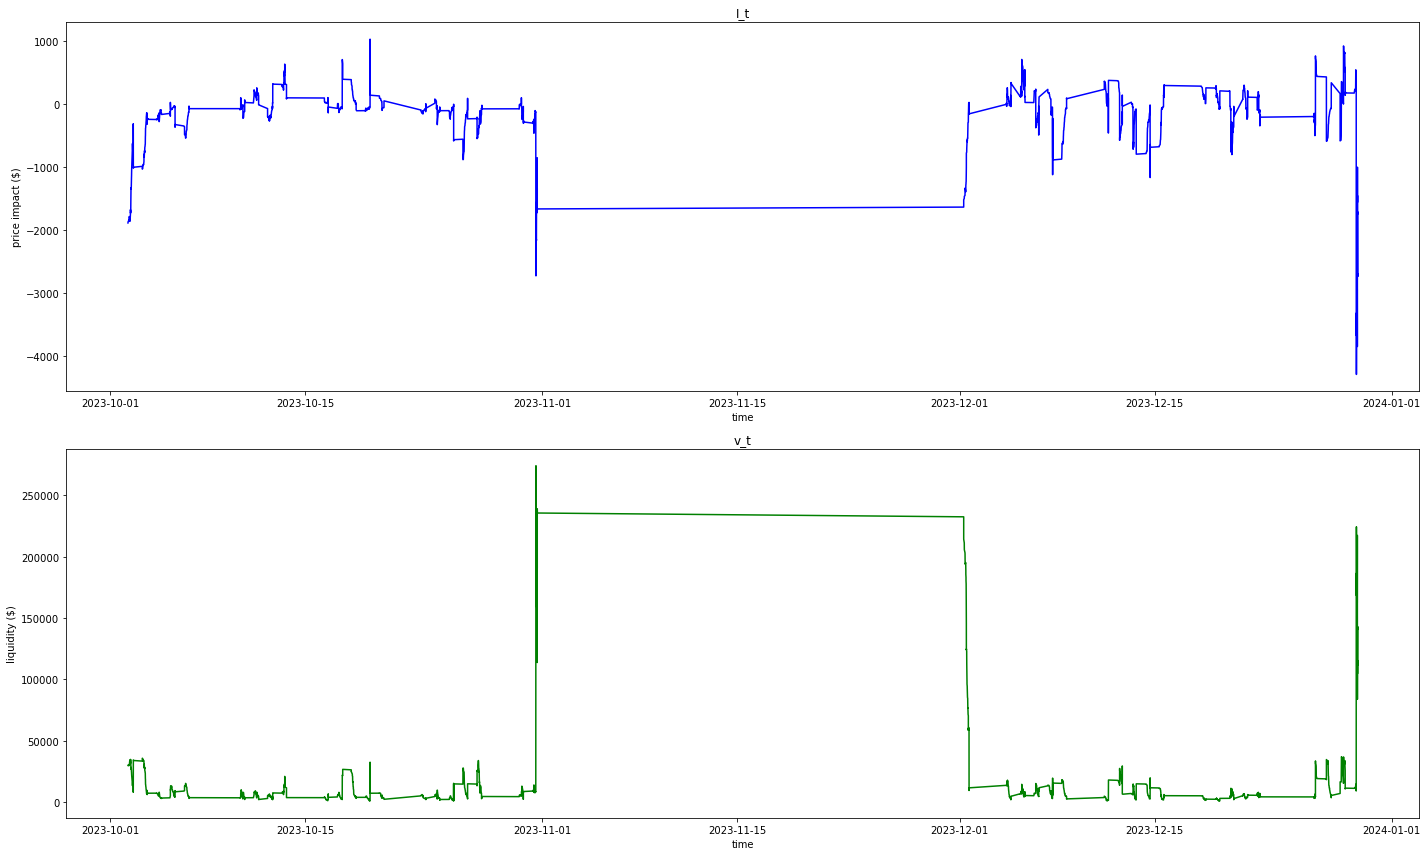

In [34]:
plt.figure(figsize=(20, 12))

# First subplot for df_it.I_t
plt.subplot(2, 1, 1)
plt.plot(df_it.I_t, color='blue')
plt.xlabel('time')
plt.ylabel('price impact ($)')
plt.title('I_t')

# Second subplot for df_it.v_t
plt.subplot(2, 1, 2)
plt.plot(df_it.v_t, color='green')
plt.xlabel('time')
plt.ylabel('liquidity ($)')
plt.title('v_t')

plt.tight_layout()
plt.show()


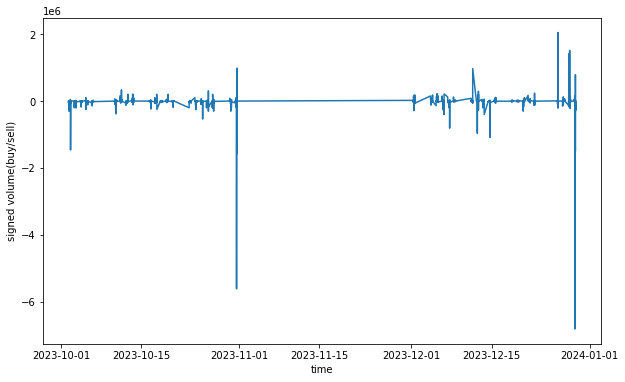

In [35]:
plt.figure(figsize=(10,6))
plt.plot(df_it.SIGNED_VOLUME)
plt.xlabel('time')
plt.ylabel('signed volume(buy/sell)')
plt.show()

In [36]:
df_it

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,SIGN,SIGNED_VOLUME,Years to Maturity,Spread,Daily_Volatility,ADV,qt,ABS_VOLUME,I_t,v_t
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:50:42,D50,3009.800,94.960769,91282CDH1,Note 0 - 1.5 Year,2024-11-15,2023-10-02,0.750,SELL,94.984375,...,-1,-30098.00,1,0.023438,1.637854,682.975123,-30098.00,30098.00,-1886.298520,30098.000000
2023-10-02 07:23:23,D28,102.313,99.757644,912828T91,Note 0 - 1.5 Year,2023-10-31,2023-10-02,1.625,SELL,99.781250,...,-1,-1023.13,0,0.027344,1.637854,682.975123,-1023.13,1023.13,-1859.431490,29681.159364
2023-10-02 08:22:38,D28,5050.000,98.827957,91282CFN6,Note 0 - 1.5 Year,2024-09-30,2023-10-02,4.250,SELL,98.847656,...,-1,-50500.00,0,0.019531,1.637854,682.975123,-88880.00,50500.00,-1850.859186,29979.634947
2023-10-02 08:33:25,D71,3838.000,99.409988,91282CAW1,Note 0 - 1.5 Year,2023-11-15,2023-10-02,0.250,SELL,99.441406,...,-1,-38380.00,0,0.027344,1.637854,682.975123,-88880.00,38380.00,-1837.995905,30100.069312
2023-10-02 09:00:46,D38,7575.000,96.804519,9128282U3,Note 0 - 1.5 Year,2024-08-31,2023-10-02,1.875,SELL,96.824219,...,-1,-75750.00,0,0.017578,1.637854,682.975123,-71871.60,75750.00,-1838.524984,30754.543300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:07,D50,13130.000,96.874832,91282CCX7,Note 0 - 1.5 Year,2024-09-15,2023-12-29,0.375,SELL,96.917969,...,-1,-131300.00,0,0.037109,1.275545,122.507953,-12203875.45,131300.00,-2647.239131,139575.184130
2023-12-29 13:51:46,D50,20200.000,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,...,-1,-202000.00,0,0.027344,1.275545,122.507953,-12203875.45,202000.00,-2671.123122,140470.156315
2023-12-29 13:51:46,D28,25250.000,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,...,-1,-252500.00,1,0.031250,1.275545,122.507953,-12203875.45,252500.00,-2709.750023,142076.305931


## old

In [ ]:
broker_performance = []
broker_daily_data = dealer_resample_sell(['whole_market', '08:00', '17:30'])

for dealer, data in broker_daily_data.items():
    if data.empty:  # Skip if the broker's data is empty
        continue

    broker_data_with_impact = concave_propagator_model(data)
    avg_impact, impact_volatility, max_impact = calculate_performance_metrics(broker_data_with_impact)
    broker_performance.append((dealer, avg_impact, impact_volatility, max_impact))

# Create DataFrame from broker performance data
broker_performance_df = pd.DataFrame(broker_performance, columns=['Dealer', 'Avg Impact', 'Impact Volatility', 'Max Impact'])
broker_performance_df = broker_performance_df.dropna()
# Calculate the 90th percentile of Avg Impact
percentile_95_threshold = np.percentile(broker_performance_df['Avg Impact'], 95)

for time in time_ranges:
    print(time)
    broker_performance = []
    broker_daily_data = dealer_resample_sell(time)
    for dealer, data in broker_daily_data.items():
        if data.empty:  # Skip if the broker's data is empty
            # print(f"Skipping broker {dealer} due to empty data")
            continue

        broker_data_with_impact = concave_propagator_model(data)

        avg_impact, impact_volatility, max_impact = calculate_performance_metrics(broker_data_with_impact)

        broker_performance.append((dealer, avg_impact, impact_volatility, max_impact))

    broker_performance_df = pd.DataFrame(broker_performance, columns=['Dealer', 'Avg Impact', 'Impact Volatility', 'Max Impact'])

    top_brokers_df = broker_performance_df[broker_performance_df['Avg Impact'] >= percentile_95_threshold]

    # Sort brokers by Avg Impact in descending order (higher impact ranks higher)
    top_brokers_df = top_brokers_df.sort_values(by='Avg Impact', ascending=False)

    print(f"Top Brokers above 90th percentile for time range {time}:")
    print(top_brokers_df)

('pre_market', '08:00', '09:30')
Top Brokers above 90th percentile for time range ('pre_market', '08:00', '09:30'):
   Dealer  Avg Impact  Impact Volatility  Max Impact
14    D36    0.018448           0.034690    0.058463
5     D58    0.013746           0.023646    0.041050
('morning', '09:30', '12:00')
Top Brokers above 90th percentile for time range ('morning', '09:30', '12:00'):
   Dealer  Avg Impact  Impact Volatility  Max Impact
17    D41    0.020111           0.026848    0.067930
15    D36    0.010635           0.039408    0.205762
8     D74    0.009641           0.032567    0.182887
13    D69    0.007660           0.032655    0.095700
4     D28    0.007325           0.036720    0.212356
1     D54    0.007270           0.033844    0.180475
12    D63    0.006602           0.019053    0.107344
('mid_day', '12:00', '14:00')
Top Brokers above 90th percentile for time range ('mid_day', '12:00', '14:00'):
   Dealer  Avg Impact  Impact Volatility  Max Impact
11    D71    0.017639       

**Broker Ranking Criteria for Buy-Side Trades:**

In evaluating and ranking brokers based on their execution performance in buy-side trades, the primary criterion revolves around the price impact of their trades. Price impact is a crucial metric that reflects how a broker's trades influence the market price of an asset. Specifically, for buy-side trades, price impact measures the change in price following the execution of a purchase order. The goal is to identify brokers who minimize the adverse effects of their trades on the market price, thereby securing more favorable outcomes for their clients.

**Average Price Impact:** The first and most significant criterion for ranking brokers is the average price impact of their trades. Brokers with a less negative or positive average price impact are considered to perform better. A negative price impact indicates that the market price decreased after the broker executed the trade, which is generally undesirable for buy-side clients. Conversely, brokers who consistently achieve trades with minimal or even positive price impacts are ranked higher, as they demonstrate better execution by not driving the price down through their trades.

**Impact Volatility:** The second criterion is the volatility of the price impact. This metric measures the consistency of a broker's execution performance. Brokers with lower impact volatility are preferred, as they provide more predictable and stable execution outcomes. High volatility in price impact suggests that a broker's performance is erratic, which may be detrimental to clients who value reliability and stability in trade execution.

**Maximum Price Impact:** The third criterion is the maximum price impact observed in the broker's trades. This metric highlights the worst-case scenario in terms of price impact, providing insight into how badly a broker's trades can influence the market. Brokers with lower maximum price impacts are favored, as they demonstrate an ability to avoid significant negative impacts even in challenging market conditions.

**Ranking Methodology:**
Brokers are ranked by comparing their performance across these three criteria, with particular emphasis on the average price impact. The ranking prioritizes brokers who consistently achieve higher average impacts (i.e., less negative or positive impacts), lower impact volatility, and lower maximum impacts. This comprehensive approach ensures that brokers who not only minimize the immediate adverse effects of their trades but also maintain consistency and control over their execution are recognized as top performers.

In summary, brokers are ranked based on their ability to minimize price impact, maintain consistency in their execution, and avoid extreme negative impacts, all of which are critical for buy-side clients seeking to optimize their trading outcomes.

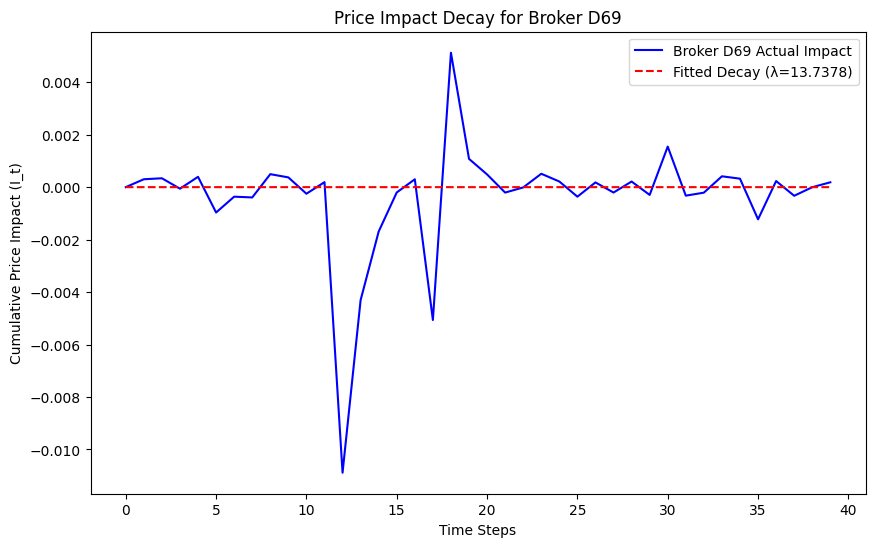

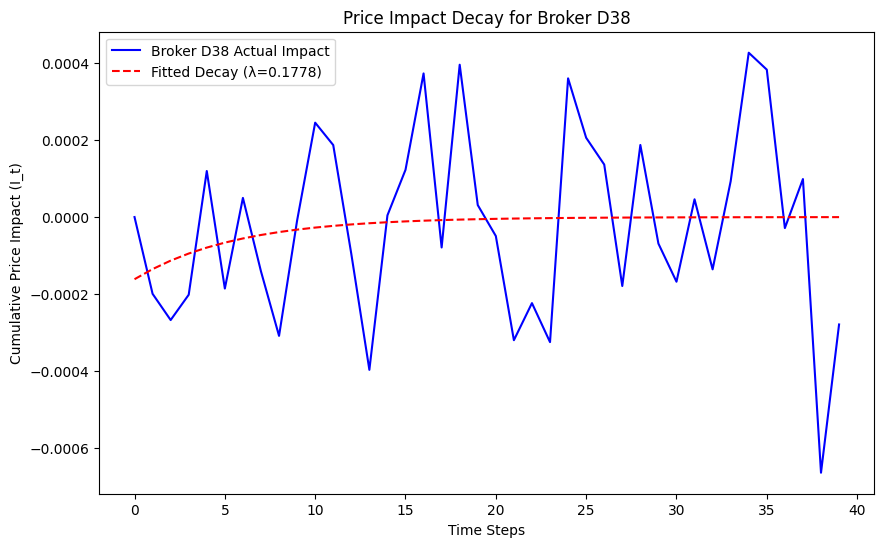

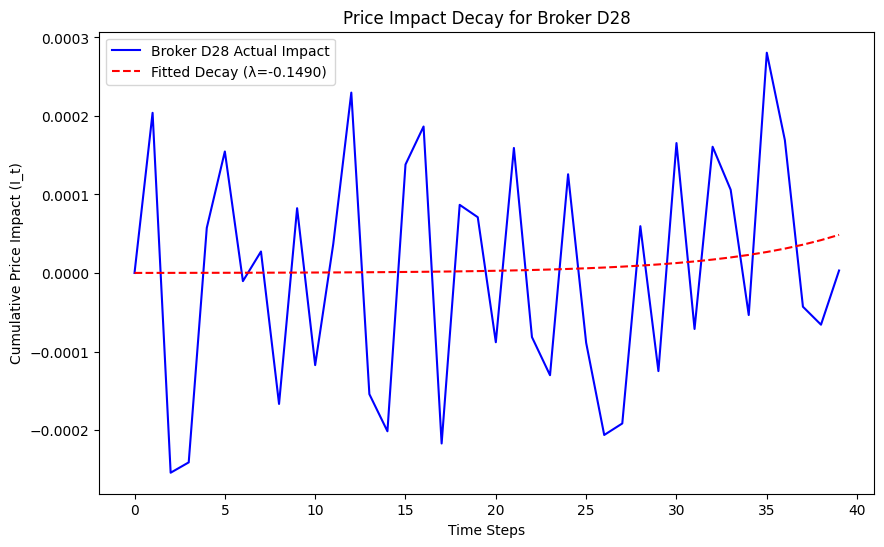

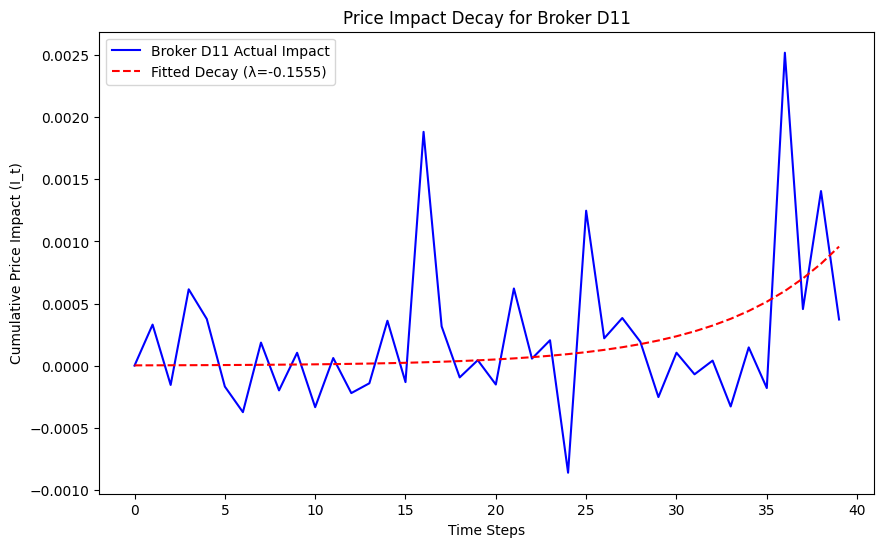

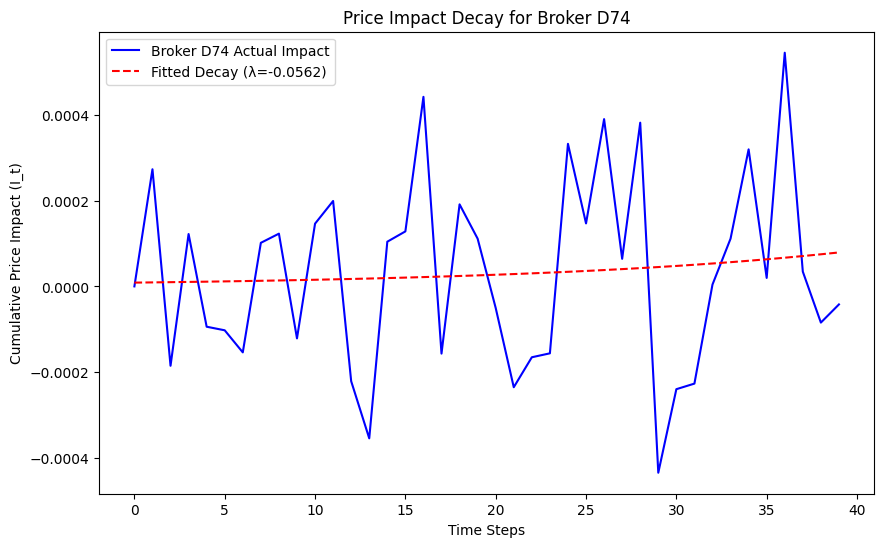

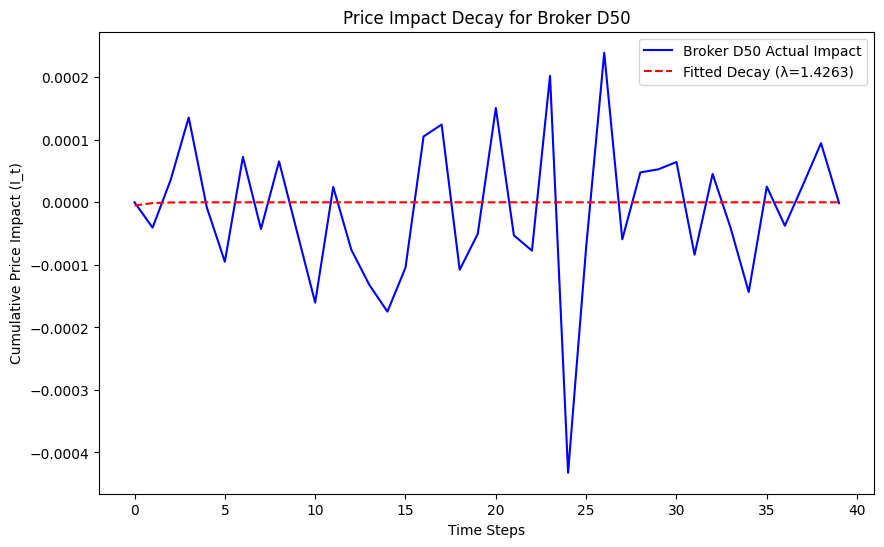

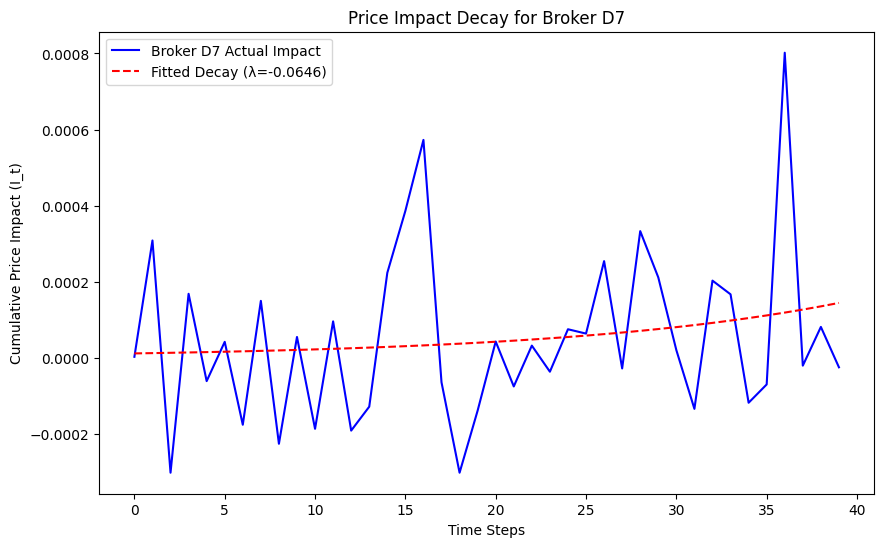

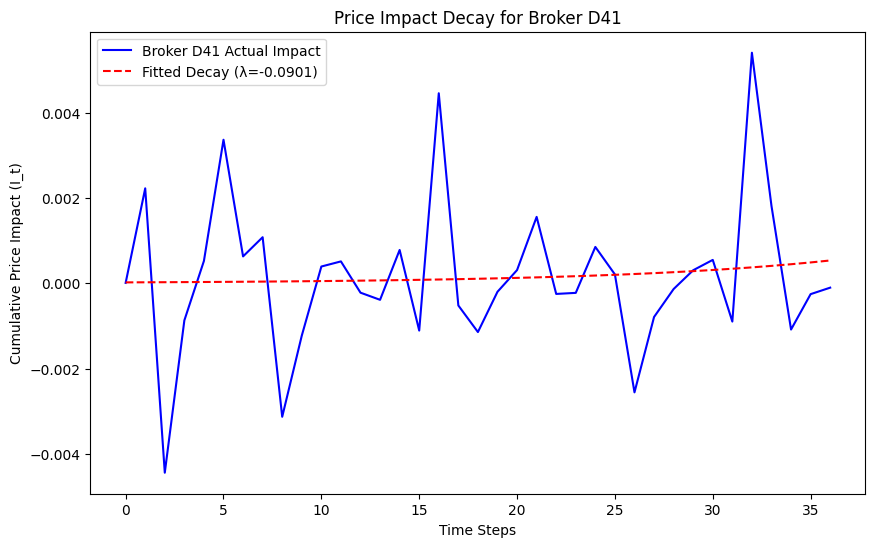

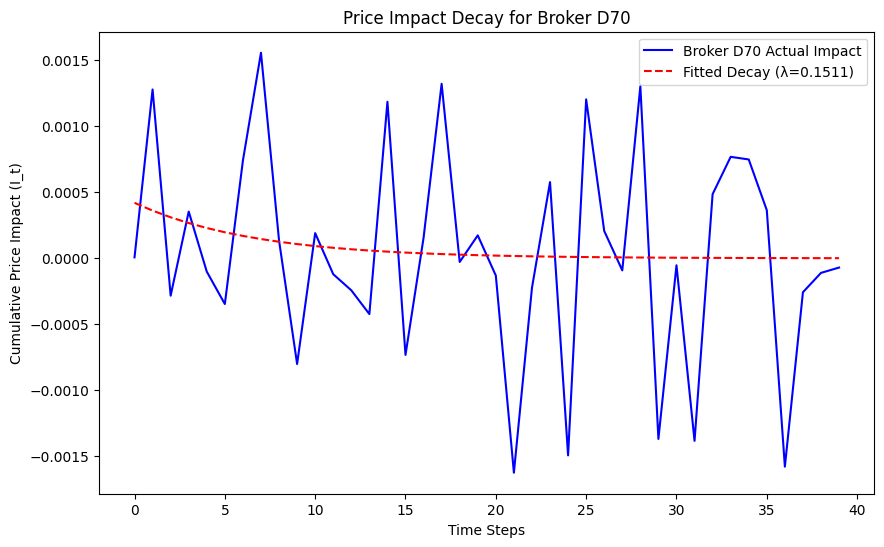

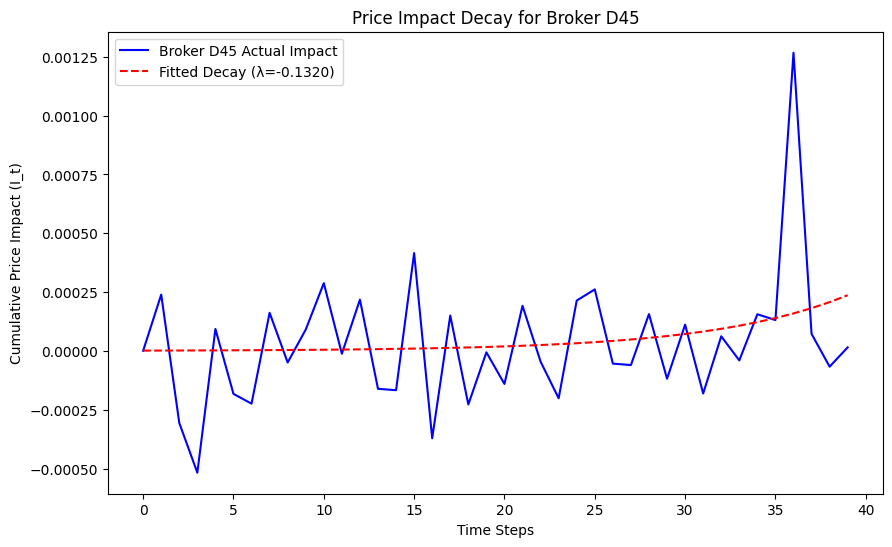

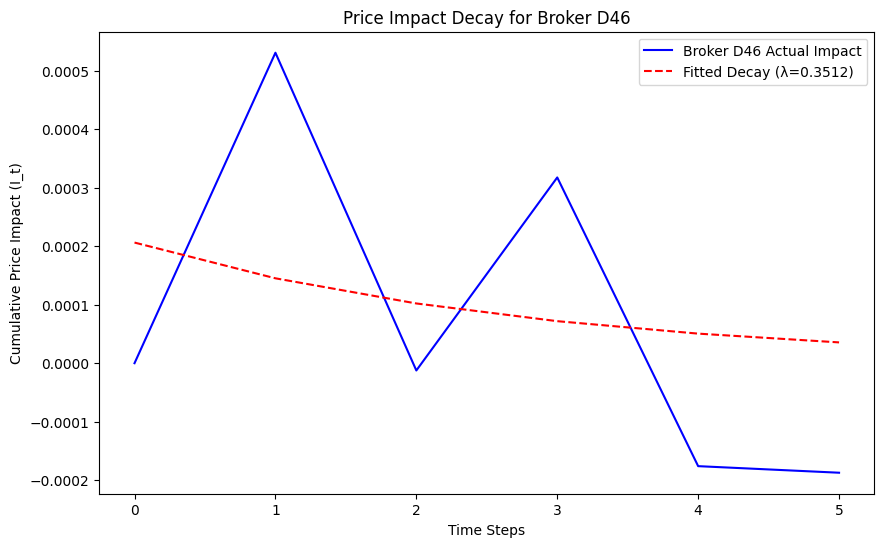

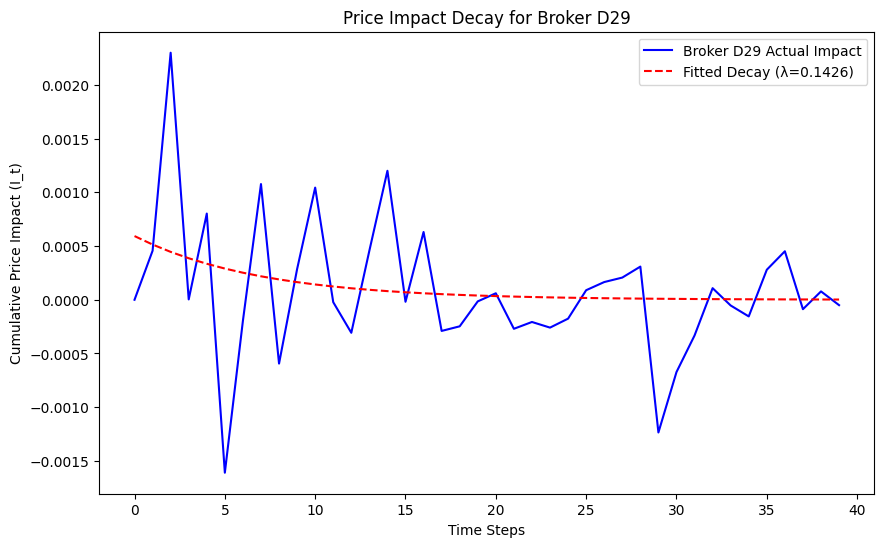

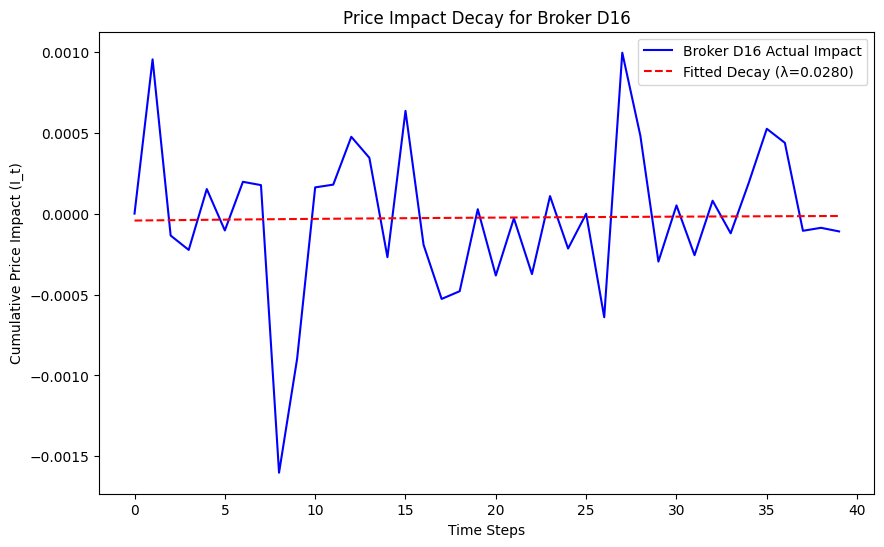

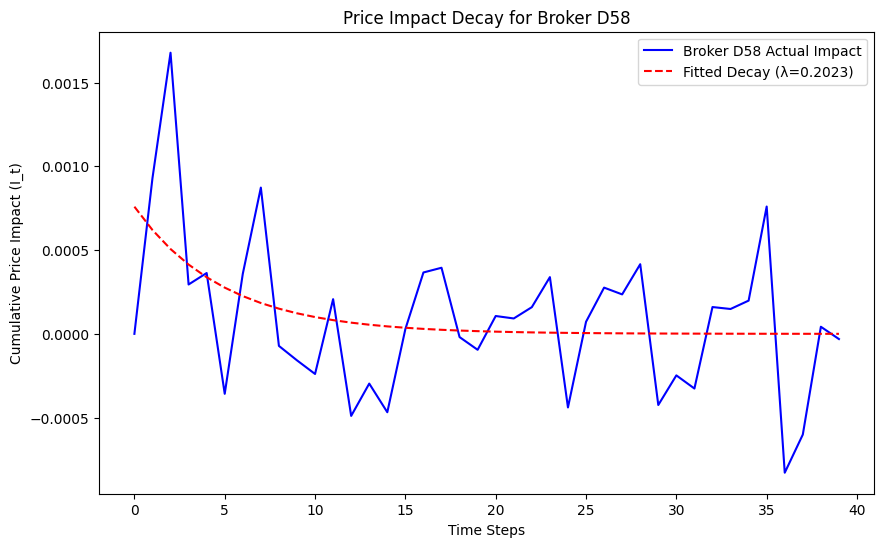

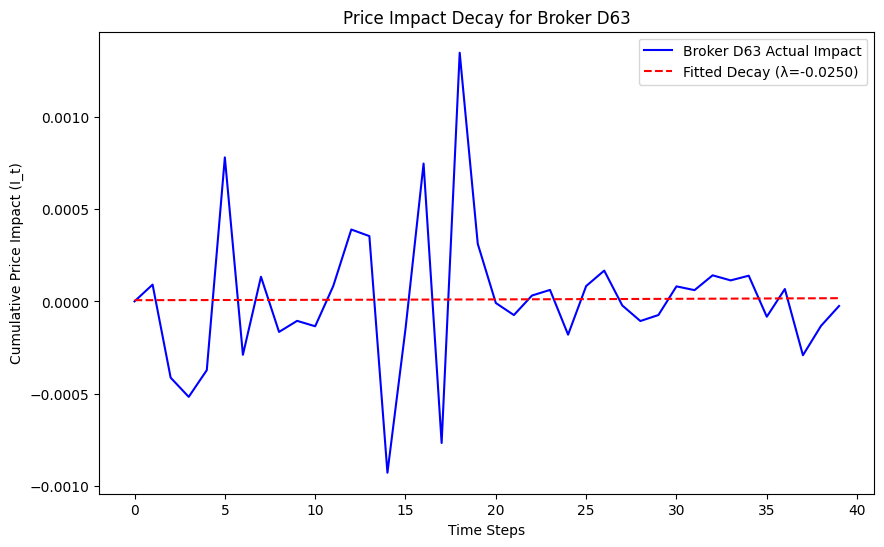

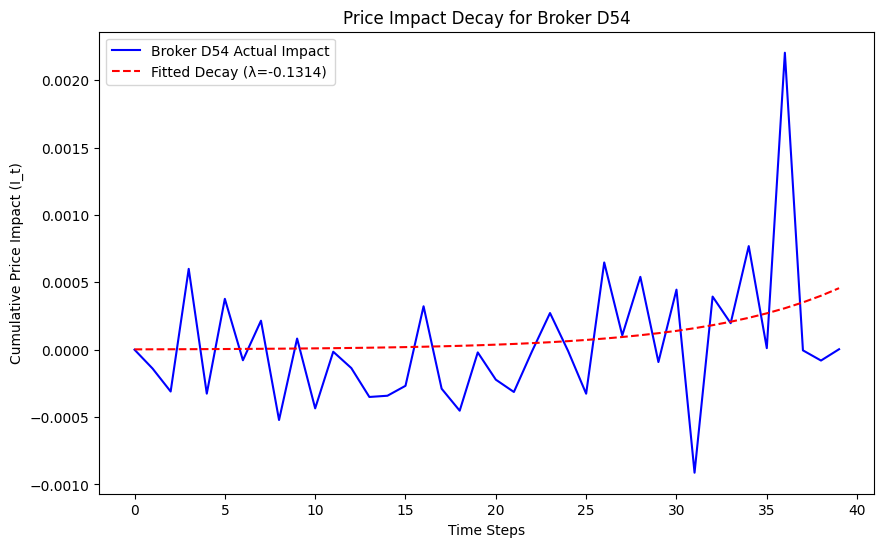

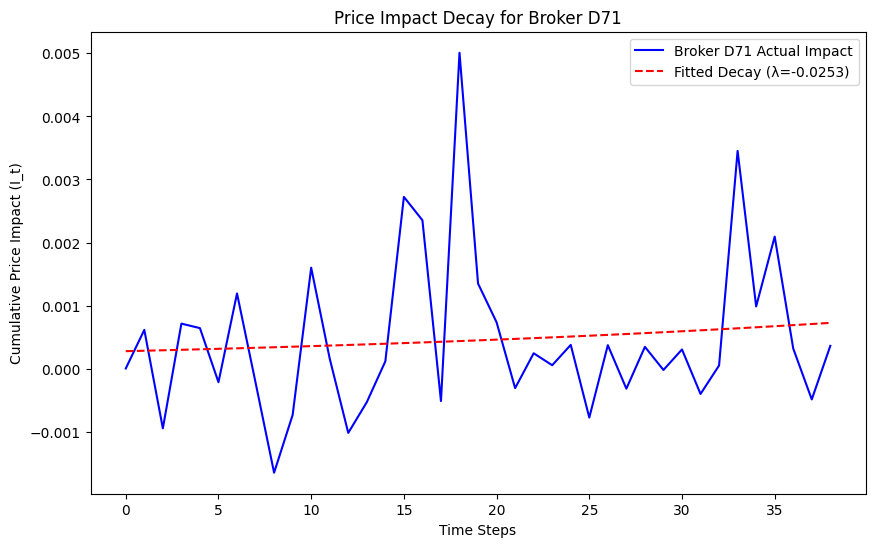

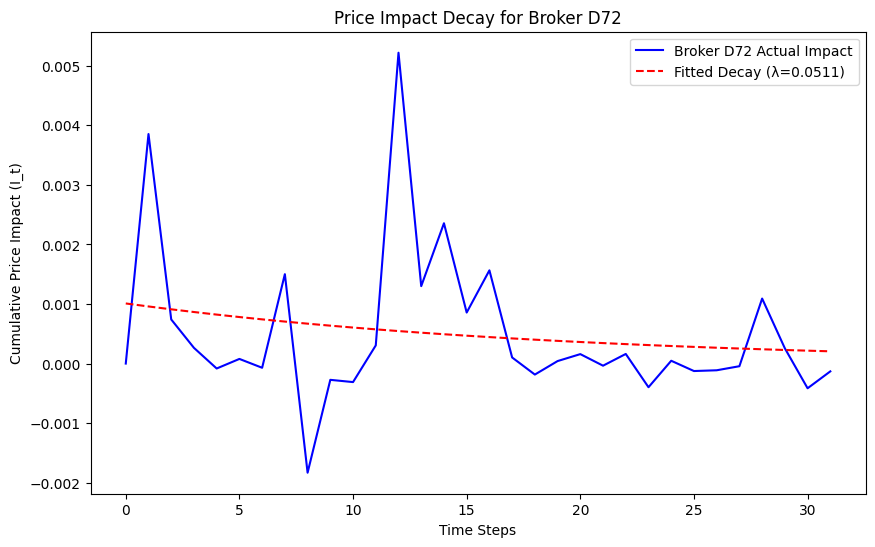

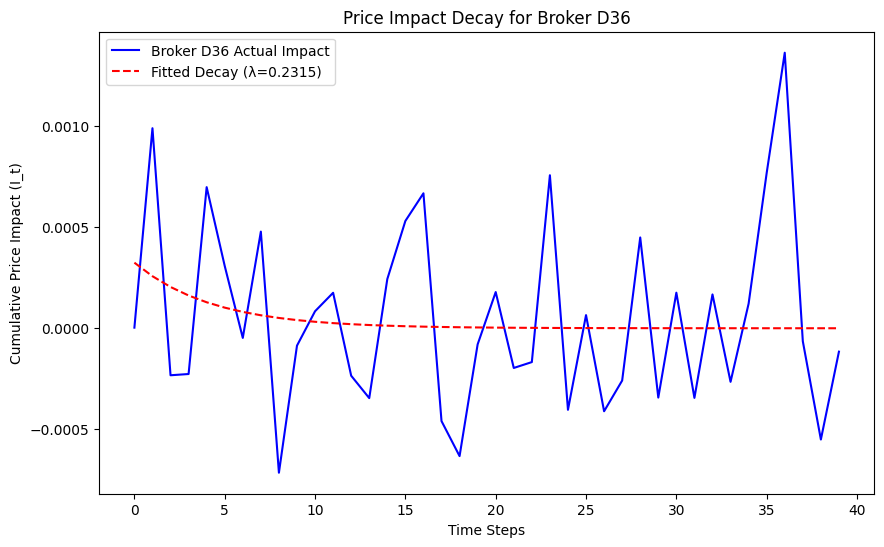

Error: 'I_t' not found for broker D30


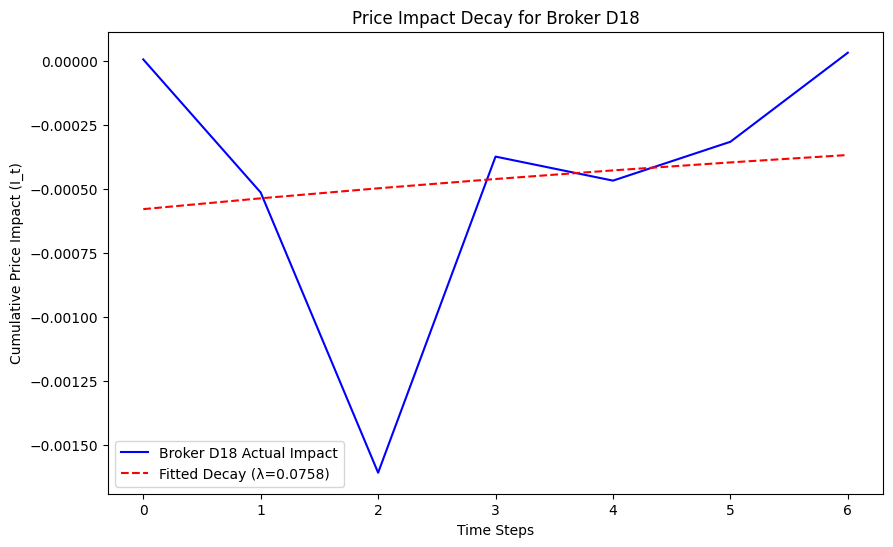

Could not fit decay model for broker D37


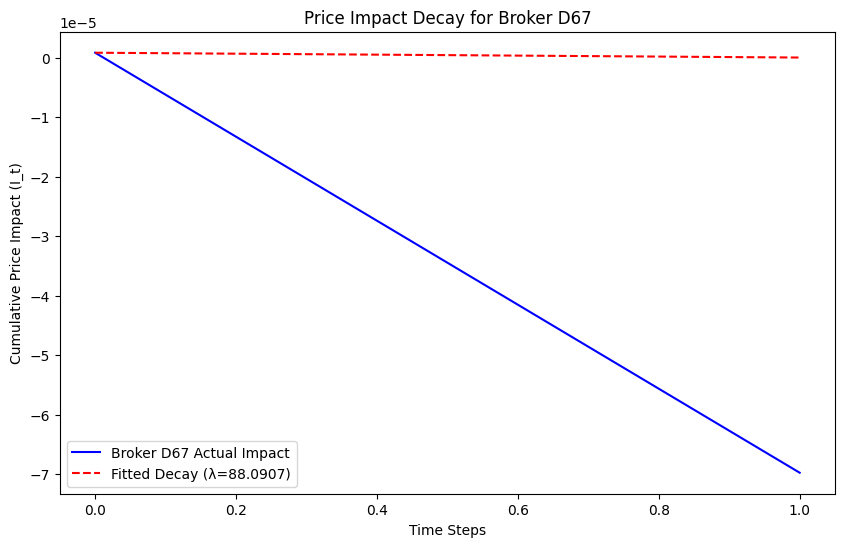

Error: 'I_t' not found for broker D79
Error: 'I_t' not found for broker D6
Error: 'I_t' not found for broker D61
Error: 'I_t' not found for broker D31
Error: 'I_t' not found for broker D12
Error: 'I_t' not found for broker D24
Error: 'I_t' not found for broker D1
Error: 'I_t' not found for broker D8


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the decay function to be fitted
def decay_func(t, I_0, lambda_):
    return I_0 * np.exp(-lambda_ * t)

# Initialize dictionary to store decay rates
broker_decay_rates = {}

# Apply the model to each broker's data
for dealer, data in broker_daily_data.items():
    # Calculate price impact using the model and ensure 'I_t' is created
    broker_data_with_impact = concave_propagator_model(data)

    # Check if 'I_t' exists
    if 'I_t' not in broker_data_with_impact.columns:
        print(f"Error: 'I_t' not found for broker {dealer}")
        continue

    # Continue with decay fitting and plotting
    t = np.arange(len(broker_data_with_impact))
    I_t = broker_data_with_impact['I_t']

    # Fit the decay model to the cumulative impact data
    try:
        popt, _ = curve_fit(decay_func, t, I_t, p0=(I_t.iloc[0], 0.01))
        I_0, lambda_ = popt
        broker_decay_rates[dealer] = lambda_

        # Plot the actual impact and fitted decay curve
        plt.figure(figsize=(10, 6))
        plt.plot(t, I_t, label=f"Broker {dealer} Actual Impact", color='blue')
        plt.plot(t, decay_func(t, I_0, lambda_), label=f"Fitted Decay (λ={lambda_:.4f})", linestyle='--', color='red')
        plt.title(f"Price Impact Decay for Broker {dealer}")
        plt.xlabel('Time Steps')
        plt.ylabel('Cumulative Price Impact (I_t)')
        plt.legend()
        plt.show()

    except RuntimeError:
        print(f"Could not fit decay model for broker {dealer}")

In [ ]:
# Filter and rank brokers with decay rates between 0 and 1 (indicating better performance)
filtered_decay_rates = {broker: decay_rate for broker, decay_rate in broker_decay_rates.items() if 0.2 < decay_rate <= 0.5}

# Sort the filtered brokers in descending order of decay rates
sorted_filtered_decay_rates = sorted(filtered_decay_rates.items(), key=lambda x: x[1], reverse=True)

# Display the filtered rankings
print("Filtered Broker Ranking based on Decay Rates (λ between 0 and 1):")
for rank, (broker, decay_rate) in enumerate(sorted_filtered_decay_rates, start=1):
    print(f"Rank {rank}: Broker {broker} with Decay Rate λ = {decay_rate:.4f}")

# If no brokers meet the criteria
if not sorted_filtered_decay_rates:
    print("No brokers meet the performance criteria (0 < λ <= 1).")

Filtered Broker Ranking based on Decay Rates (λ between 0 and 1):
Rank 1: Broker D46 with Decay Rate λ = 0.3512
Rank 2: Broker D36 with Decay Rate λ = 0.2315
Rank 3: Broker D58 with Decay Rate λ = 0.2023


In [ ]:
# Given total volume for October and December
october_total_vol = october_total_vol  # Given value for October
december_total_vol = december_total_vol  # Given value for December

# Calculate the number of trading days for October and December
october_trading_days = data_resampled['ACCEPTEDVOL']['2023-10'].count()
december_trading_days = data_resampled['ACCEPTEDVOL']['2023-12'].count()
print(october_trading_days)
print(december_trading_days)
# Calculate ADV for October and December
october_adv = october_total_vol / october_trading_days
december_adv = december_total_vol / december_trading_days

print(f"October ADV: {october_adv}")
print(f"December ADV: {december_adv}")

861
1046
October ADV: 20448.0747688734
December ADV: 15376.495107074568


In [ ]:
october_top_brokers_data

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,297.95,3,0.027344
2023-10-02 06:47:43,D28,436.32,73.531450,912810RP5,Note >10 Year,2045-11-15,2023-10-02,3.000,BUY,73.632812,73.460938,1,436.32,22,0.085938
2023-10-02 06:47:43,D74,1646.30,94.050981,91282CHT1,Note 5.5 - 10 Year,2033-08-15,2023-10-02,3.875,BUY,94.066406,94.050781,1,1646.30,9,0.007812
2023-10-02 06:47:43,D50,444.40,92.769731,912810TU2,Note >10 Year,2043-08-15,2023-10-02,4.375,BUY,92.816406,92.769531,1,444.40,19,0.023438
2023-10-02 06:50:42,D50,3009.80,94.960769,91282CDH1,Note 0 - 1.5 Year,2024-11-15,2023-10-02,0.750,SELL,94.984375,94.937500,-1,-3009.80,1,0.023438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-31 16:20:15,D7,20.20,92.011919,91282CHT1,Note 5.5 - 10 Year,2033-08-15,2023-10-31,3.875,BUY,92.015625,92.000000,1,20.20,9,0.007812
2023-10-31 16:24:58,D74,434.30,91.992388,91282CHT1,Note 5.5 - 10 Year,2033-08-15,2023-10-31,3.875,BUY,92.003906,91.988281,1,434.30,9,0.007812
2023-10-31 16:29:54,D63,5632.77,99.847824,91282CJE2,Note 1.5 - 3.5 Year,2025-10-31,2023-10-31,5.000,BUY,99.851562,99.843750,1,5632.77,2,0.003906


In [ ]:
 def calculate_price_impact_for_brokers(broker_data, adv_value, c=0.3):
    """
    Calculate price impact for a specific broker's data.
    """
    broker_data = broker_data.copy()
    broker_data['RETURN'] = broker_data['PRICE'].pct_change()
    broker_data['MARKET_ACTIVITY'] = broker_data['Spread']
    broker_data['DELTA_F'] = broker_data['MARKET_ACTIVITY'].diff()
    broker_data.dropna(inplace=True)

    n_scaled_term = np.zeros(len(broker_data))
    I_t_list = np.zeros(len(broker_data))

    initial_I_t = broker_data['VOL'].iloc[0] * broker_data['MARKET_ACTIVITY'].iloc[0] / adv_value
    previous_I_t = initial_I_t

    for i in range(1, len(broker_data)):
        market_activity = broker_data['MARKET_ACTIVITY'].iloc[i]
        delta_f = broker_data['DELTA_F'].iloc[i]
        sigma_value = broker_data['VOL'].iloc[i]

        sign_delta_f = np.sign(delta_f)

        # Apply the concave propagator model with the exponent c
        current_I_t = previous_I_t + (-0.7 * previous_I_t * 1 +
                                      sigma_value * sign_delta_f * (abs(delta_f) ** c) / (adv_value ** (c / 2)))

        n_scaled_term[i] = current_I_t - previous_I_t
        I_t_list[i] = current_I_t
        previous_I_t = current_I_t

    broker_data['n_scaled_term'] = n_scaled_term
    broker_data['I_t'] = I_t_list

    return broker_data[['I_t', 'DEALER']]  # Preserve the DEALER column

# Now use this function with your existing code:
october_broker_results = calculate_price_impact_for_brokers(october_top_brokers_data, october_adv, c=0.3)
december_broker_results = calculate_price_impact_for_brokers(december_top_brokers_data, december_adv, c=0.3)

KeyError: 'VOL'

In [ ]:
october_broker_results

,I_t,DEALER
TIMESTAMP,,
2023-10-02 06:47:43,0.000000,D28
2023-10-02 06:47:43,-0.012893,D74
2023-10-02 06:47:43,-0.004311,D50
2023-10-02 06:50:42,-0.001293,D50
2023-10-02 06:50:42,-0.009762,D7
...,...,...
2023-10-31 16:18:04,0.000035,D74
2023-10-31 16:20:15,0.002601,D7
2023-10-31 16:24:58,0.000780,D74


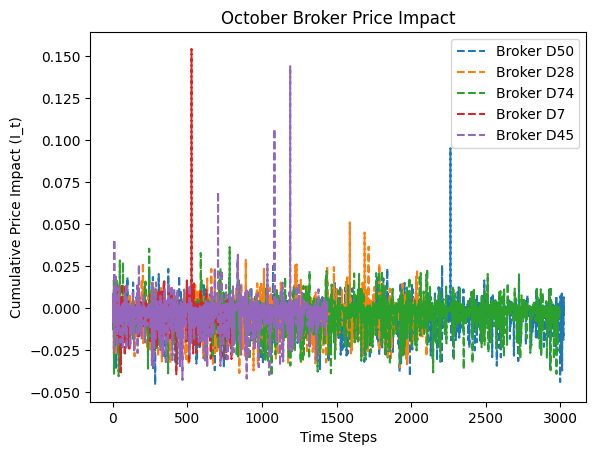

In [ ]:
# Assuming 'october_broker_results' is a DataFrame with broker data and 'DEALER' is a column in that DataFrame
for dealer in october_brokers.index:
    broker_data = october_broker_results[october_broker_results['DEALER'] == dealer]

    if broker_data.empty:
        print(f"No data found for broker {dealer}")
        continue

    plt.plot(range(len(broker_data)), broker_data['I_t'], label=f"Broker {dealer}", linestyle='--')

plt.xlabel("Time Steps")
plt.ylabel("Cumulative Price Impact (I_t)")
plt.title("October Broker Price Impact")
plt.legend()
plt.show()

In [ ]:
broker_metrics = []

for dealer in october_brokers.index:
    broker_data = october_broker_results[october_broker_results['DEALER'] == dealer]

    avg_impact = broker_data['I_t'].mean()
    impact_volatility = broker_data['I_t'].std()
    max_impact = broker_data['I_t'].max()

    broker_metrics.append({
        'Dealer': dealer,
        'Avg Impact': avg_impact,
        'Impact Volatility': impact_volatility,
        'Max Impact': max_impact
    })

# Convert to DataFrame for easy comparison
broker_metrics_df = pd.DataFrame(broker_metrics)

# Sort by Avg Impact (you can also sort by other metrics depending on your priority)
broker_ranked = broker_metrics_df.sort_values(by='Avg Impact')

print(broker_ranked)

  Dealer  Avg Impact  Impact Volatility  Max Impact
1    D28   -0.003018           0.008313    0.051044
4    D45   -0.002773           0.009634    0.143996
2    D74   -0.002745           0.007569    0.036323
0    D50   -0.002487           0.007128    0.095153
3     D7   -0.002397           0.008821    0.154287


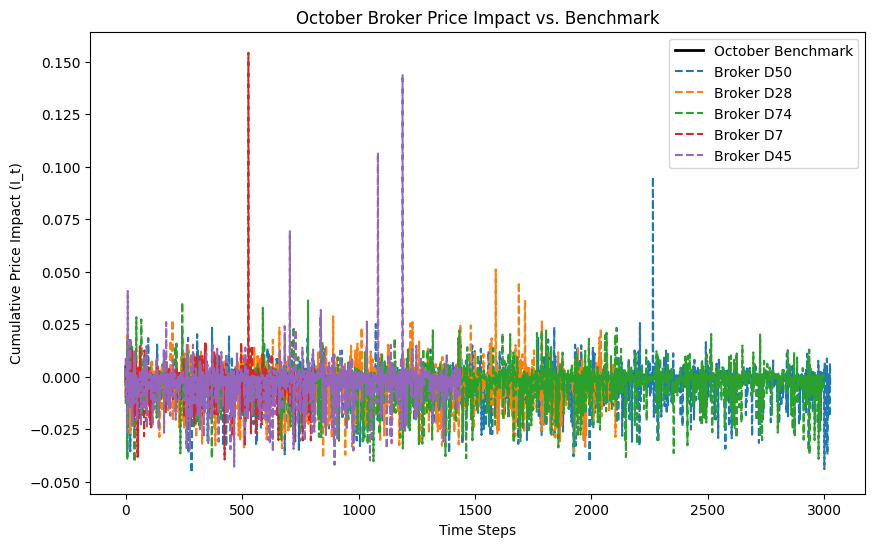

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the October benchmark curve
#plt.plot(range(len(october_results)),
#         october_results['I_t'],
#         label='October Benchmark', color='black', linewidth=2)

# Plot each broker's curve
for dealer in october_brokers.index:  # Assuming top_5_brokers contains the selected top 5
    broker_data = october_broker_results[october_broker_results['DEALER'] == dealer]
    plt.plot(range(len(broker_data)), broker_data['I_t'], label=f"Broker {dealer}", linestyle='--')

# Add titles and labels
plt.title('October Broker Price Impact vs. Benchmark')
plt.xlabel('Time Steps')
plt.ylabel('Cumulative Price Impact (I_t)')
plt.legend()
plt.show()


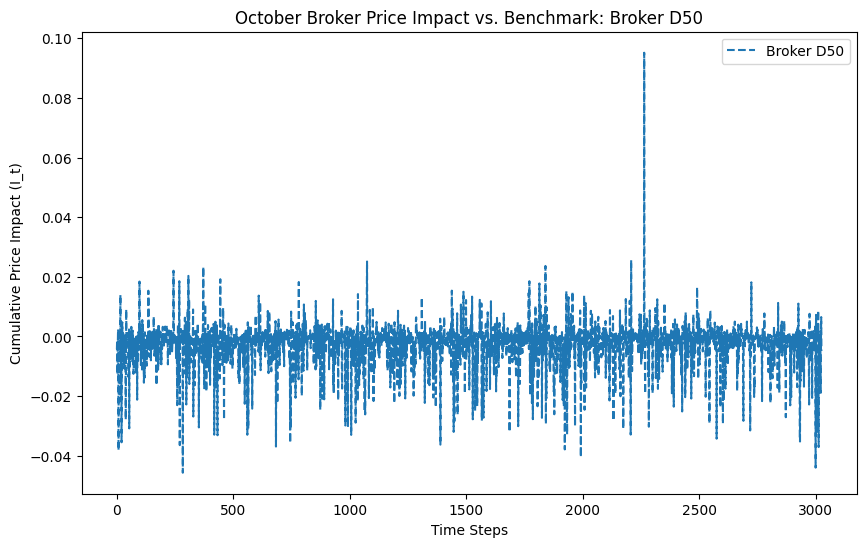

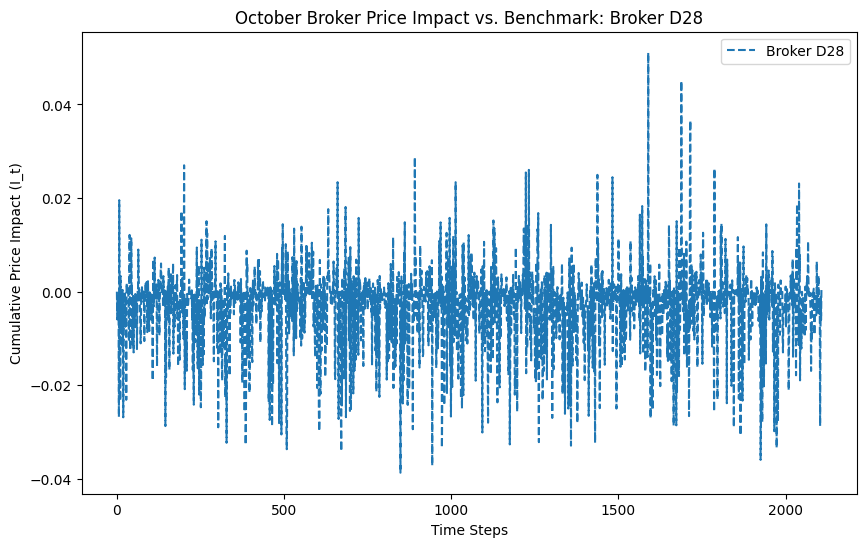

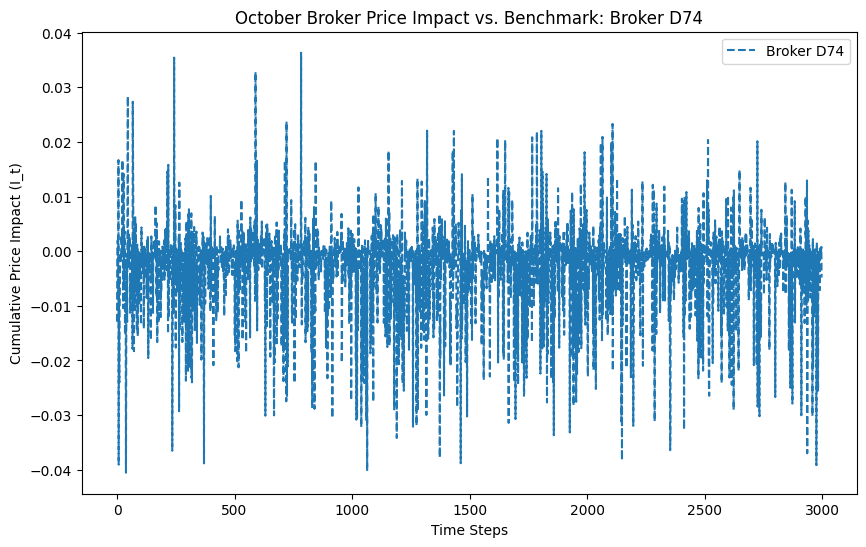

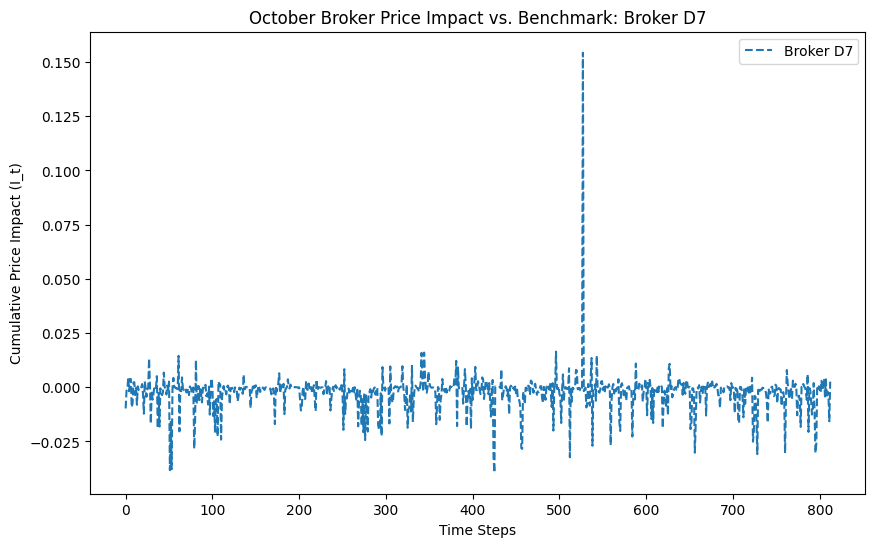

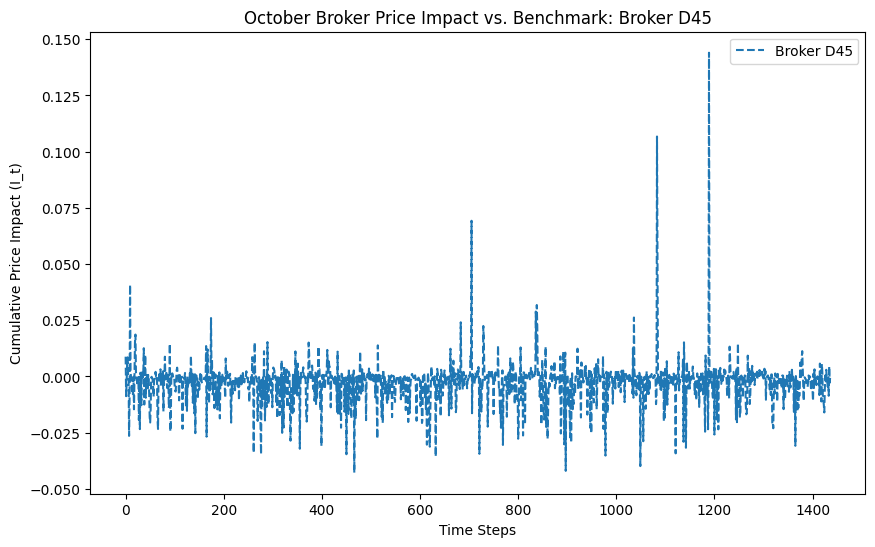

In [ ]:
import matplotlib.pyplot as plt

# Plot each broker's curve separately with the benchmark
for dealer in october_brokers.index:  # Assuming october_brokers contains the selected top 5
    plt.figure(figsize=(10, 6))

    # Plot the October benchmark curve
    #plt.plot(range(len(october_results)),
    #         october_results['I_t'],
    #         label='October Benchmark', color='black', linewidth=2)

    # Plot the broker's curve
    broker_data = october_broker_results[october_broker_results['DEALER'] == dealer]
    plt.plot(range(len(broker_data)), broker_data['I_t'], label=f"Broker {dealer}", linestyle='--')

    # Add titles and labels
    plt.title(f'October Broker Price Impact vs. Benchmark: Broker {dealer}')
    plt.xlabel('Time Steps')
    plt.ylabel('Cumulative Price Impact (I_t)')
    plt.legend()

    # Show the plot
    plt.show()